In [ ]:
#| default_exp image_gen.synthetic_noise_at_center

In [ ]:
#| hide
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
#| export
from cv_tools.core import *
from cv_tools.imports import *
from typing import Optional, List, Tuple

In [ ]:
from sklearn.model_selection import train_test_split
import random

In [ ]:
# getting common files
im_path=Path(r'/home/hasan/Schreibtisch/projects/data/easy_pin_detection/missing_pin_sn_images')
msk_path = Path(r'/home/hasan/Schreibtisch/projects/data/easy_pin_detection/missing_pin_sn_masks')
common_files_ = set(get_name_(im_path.ls())).intersection(set(get_name_(msk_path.ls())))
im_dst_path = Path(r'/home/hasan/Schreibtisch/projects/data/easy_pin_detection/sn_img')
msk_dst_path = Path(r'/home/hasan/Schreibtisch/projects/data/easy_pin_detection/sn_msk')


In [ ]:
#| export
def common_files_(path1, path2):
    return set(get_name_(path1.ls())).intersection(set(get_name_(path2.ls())))

In [ ]:
# copying files
#for i in tqdm(common_files_, desc='copying files'):
	#shutil.copy(im_path/i, im_dst_path/i)
	#shutil.copy(msk_path/i, msk_dst_path/i)

In [ ]:
# checking size of the images
shapes_ = [read_img(i).shape for i in tqdm(im_dst_path.ls(), desc='checking size of images')]
np.max(shapes_, axis=0), np.min(shapes_, axis=0)

checking size of images:   0%|          | 0/128 [00:00<?, ?it/s]

(array([92, 90]), array([92, 90]))

In [ ]:
def read_and_process_images(
        image_path: Path, 
        target_size: tuple=(92, 90), 
		save_path: Path=None
    ):
    """
    Read all images from the given path, center crop or resize them to the target size.
    
    Args:
    image_path (Path): Path to the directory containing images
    target_size (tuple): Desired output size (height, width)
    
    Returns:
    list: List of processed images as numpy arrays
    """
    processed_images = []
    
    for img_file in tqdm(image_path.ls(), desc='Processing images to target size'):
        # Read the image
        img_file = Path(img_file)
        img = read_img(img_file)
        
        # Get current dimensions
        h, w = img.shape[:2]
        
        if h >= target_size[0] and w >= target_size[1]:
            # If image is larger, perform center crop
            img = center_crop(
                Image.fromarray(img), 
                desired_height=target_size[0], 
                desired_width=target_size[1], 
                height_offset=0, 
                width_offset=0
            )
            if save_path is not None:
                Path(save_path).mkdir(exist_ok=True, parents=True)
                cv2.imwrite(f'{save_path}/{img_file.name}', img)
        else:
            # If image is smaller, resize with anti-aliasing
            img = cv2.resize(img, target_size[::-1], interpolation=cv2.INTER_AREA)
            if save_path is not None:
                Path(save_path).mkdir(exist_ok=True, parents=True)
                cv2.imwrite(f'{save_path}/{img_file.name}', img)
        
        processed_images.append(img)
    
    return processed_images

In [ ]:

# Process all images in the directory
#processed_imgs = read_and_process_images(im_dst_path, save_path=im_dst_path)
#processed_msks = read_and_process_images(msk_dst_path, save_path=msk_dst_path)

Processing images to target size:   0%|          | 0/93 [00:00<?, ?it/s]

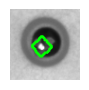

In [ ]:

sm_fn = np.random.choice(im_dst_path.ls(),1)[0]
sm_img = read_img(sm_fn)
sm_msk = read_img(msk_dst_path/sm_fn.name)
show_(overlay_mask_border_on_image_frm_img(sm_img, sm_msk))

In [ ]:
mask_indices = np.where(sm_msk >0)
center_y, center_x = int(np.mean(mask_indices[0])), int(np.mean(mask_indices[1]))
center_y, center_x

(48, 40)

In [ ]:
#| export
def create_gradient_mask(
    shape:Tuple[int,int], #Size of the mask (height, width)
    center:Tuple[int,int] #Center point of the gradient (x, y)
)->np.ndarray:
    "Create a circular gradient mask centered at `center` with size `shape`"
    y, x = np.ogrid[:shape[0], :shape[1]] # Create coordinate arrays
    mask = np.sqrt((x - center[0])**2 + (y - center[1])**2) # Calculate distance from center
    mask = mask / np.max(mask) # Normalize distances to [0, 1]
    return 1 - np.clip(mask, 0, 1) # Invert and clip to create gradient

In [ ]:
#| export
def draw_circle(
    shape_mask:np.ndarray, # The mask to draw on
    center:Tuple[int,int], # The (x, y) coordinates of the circle's center
    shape_size:int         # The diameter of the circle
)->None:
    "Draw a filled circle on the given mask"
    cv2.circle(shape_mask, center, shape_size//2, 1, -1)
    # shape_mask: The numpy array to draw on
    # center: The (x, y) coordinates of the circle's center
    # shape_size//2: The radius of the circle (half the diameter)
    # 1: The color to fill the circle with (1 for white)
    # -1: Thickness (-1 means fill the circle)

In [ ]:
#| export
def draw_arced_rectangle(
        shape_mask:np.ndarray, # The mask to draw on
        center:Tuple[int,int], # The (x, y) coordinates of the rectangle's center
        shape_size:int         # The size of the rectangle
)->None:
    "Draw a rectangle with arced corners on the given mask"
    center_x, center_y = center  # Unpack the center coordinates
    # Define the four corners of the rectangle
    rect_points = np.array([
        [center_x - shape_size//2, center_y - shape_size//2],  # Top-left
        [center_x + shape_size//2, center_y - shape_size//2],  # Top-right
        [center_x + shape_size//2, center_y + shape_size//2],  # Bottom-right
        [center_x - shape_size//2, center_y + shape_size//2]   # Bottom-left
    ], np.int32)
    cv2.fillPoly(shape_mask, [rect_points], 1)  # Fill the rectangle
    
    arc_radius = shape_size // 4  # Define the radius of the arcs
    # Draw arcs at each corner
    for x, y in [(-1, -1), (1, -1), (1, 1), (-1, 1)]:  # Loop through each corner
        cv2.ellipse(shape_mask, 
                    (center_x + x*shape_size//2, center_y + y*shape_size//2),  # Arc center
                    (arc_radius, arc_radius),  # Arc size
                    (x+1)*(y+1)*90, 0, 90, 0, -1)  # Arc parameters

In [ ]:
#| export
def draw_triangle(
        shape_mask:np.ndarray, # The mask to draw on
        center:Tuple[int,int], # The (x, y) coordinates of the triangle's center
        shape_size:int         # The size of the triangle
)->None:
    "Draw an equilateral triangle on the given mask"
    center_x, center_y = center  # Unpack the center coordinates
    # Define the three points of the triangle
    points = np.array([
        (center_x, center_y - shape_size//2),  # Top point
        (center_x - shape_size//2, center_y + shape_size//2),  # Bottom-left
        (center_x + shape_size//2, center_y + shape_size//2)   # Bottom-right
    ], np.int32)
    cv2.fillPoly(shape_mask, [points], 1)  # Fill the triangle

In [ ]:
#| export
def draw_line(
        shape_mask:np.ndarray, # The mask to draw on
        center:Tuple[int,int], # The (x, y) coordinates of the line's center
        shape_size:int         # The size of the line
)->None:
    "Draw a line with various styles on the given mask"
    center_x, center_y = center  # Unpack the center coordinates
    thickness = max(shape_size//10, 3)  # Calculate line thickness
    line_type = np.random.choice(['straight', 'vertical', 'horizontal', 'bent'])  # Randomly choose line type
    
    if line_type == 'straight':
        angle = np.random.uniform(0, 2*np.pi)  # Random angle
        dx, dy = int(shape_size * np.cos(angle)), int(shape_size * np.sin(angle))  # Calculate end points
        cv2.line(shape_mask, (center_x - dx, center_y - dy), (center_x + dx, center_y + dy), 1, thickness)
    elif line_type == 'vertical':
        cv2.line(shape_mask, (center_x, center_y - shape_size//2), (center_x, center_y + shape_size//2), 1, thickness)
    elif line_type == 'horizontal':
        cv2.line(shape_mask, (center_x - shape_size//2, center_y), (center_x + shape_size//2, center_y), 1, thickness)
    else:  # bent line
        mid_x, mid_y = center_x + np.random.randint(-shape_size//4, shape_size//4), center_y + np.random.randint(-shape_size//4, shape_size//4)  # Random midpoint
        cv2.line(shape_mask, (center_x - shape_size//2, center_y - shape_size//2), (mid_x, mid_y), 1, thickness)  # First segment
        cv2.line(shape_mask, (mid_x, mid_y), (center_x + shape_size//2, center_y + shape_size//2), 1, thickness)  # Second segment

In [ ]:
#| export
def draw_parabola(
        shape_mask:np.ndarray, # The mask to draw on
        center:Tuple[int,int], # The (x, y) coordinates of the parabola's center
        shape_size:int         # The size of the parabola
)->None:
    "Draw a parabola on the given mask"
    center_x, center_y = center  # Unpack the center coordinates
    thickness = max(shape_size//20, 3)  # Calculate parabola thickness
    for x in range(-shape_size//2, shape_size//2):  # Loop through x-coordinates
        y = int((x**2) / (shape_size/4))  # Calculate y-coordinate using parabola equation
        cv2.circle(shape_mask, (center_x + x, center_y + y - shape_size//4), thickness, 1, -1)  # Draw point

In [ ]:
#| export
def draw_random_polygon(
        shape_mask:np.ndarray, # The mask to draw on
        center:Tuple[int,int], # The (x, y) coordinates of the polygon's center
        shape_size:int         # The size of the polygon
)->None:
    "Draw a random polygon on the given mask"
    center_x, center_y = center  # Unpack the center coordinates
    num_vertices = np.random.randint(3, 8)  # Random number of vertices
    angles = np.linspace(0, 2*np.pi, num_vertices, endpoint=False)  # Evenly spaced angles
    np.random.shuffle(angles)  # Shuffle angles for randomness
    points = []
    for angle in angles:  # Generate points for each angle
        r = np.random.uniform(0.5, 1.0) * shape_size // 2  # Random radius
        x = int(center_x + r * np.cos(angle))  # Calculate x-coordinate
        y = int(center_y + r * np.sin(angle))  # Calculate y-coordinate
        points.append((x, y))
    cv2.fillPoly(shape_mask, [np.array(points)], 1)  # Fill the polygon
    cv2.polylines(shape_mask, [np.array(points)], True, 1, thickness=max(shape_size//20, 2))

In [ ]:
def add_random_shape_to_mask_center(
        image:np.ndarray, # The image to draw on
        mask:np.ndarray, # The mask to draw on
        shape_size_fraction:float=0.5, # The size of the shape as a fraction of the mask size
        blend_factor:float=0.7, # The blend factor for the shape
        shape_type:Optional[str]=None # The type of shape to draw (optional)
)->Tuple[np.ndarray, str]:
    "Add a random or specified shape to the center of the mask"
    mask_indices = np.where(mask > 0)
    center = (int(np.mean(mask_indices[1])), int(np.mean(mask_indices[0])))
    
    object_size = max(np.ptp(mask_indices[0]), np.ptp(mask_indices[1]))
    shape_size = int(object_size * shape_size_fraction)
    
    gradient_mask = create_gradient_mask(image.shape, center)
    
    shape_functions = {
        'circle': draw_circle,
        'arced_rectangle': draw_arced_rectangle,
        'triangle': draw_triangle,
        'line': draw_line,
        'parabola': draw_parabola,
        'random': draw_random_polygon
    }
    
    if shape_type is None or shape_type not in shape_functions:
        shape_type = np.random.choice(list(shape_functions.keys()))
    
    shape_mask = np.zeros_like(image, dtype=np.float32)
    
    shape_functions[shape_type](shape_mask, center, shape_size)
    
    # Apply stronger blur for random polygons
    if shape_type == 'random':
        shape_mask = cv2.GaussianBlur(shape_mask, (21, 21), 0)
    else:
        shape_mask = cv2.GaussianBlur(shape_mask, (15, 15), 0)
    
    combined_mask = shape_mask * gradient_mask
    
    result = image.copy().astype(np.float32)
    result = result * (1 - combined_mask * blend_factor) + 0 * (combined_mask * blend_factor)
    result = np.clip(result, 0, 255).astype(np.uint8)
    
    return result, shape_type

In [ ]:
#| export
def apply_random_shape_and_save(
    image_path:str, # Path to the input image file
    mask_path:str, # Path to the input mask file
    image_dst_path:str, # Directory to save the output files
	mask_dst_path:str, # Directory to save the output files
    shape_size_fraction:float=0.5, # Size of the shape as a fraction of the mask size
    blend_factor:float=0.7, # Blend factor for the shape
    num_generated_images:int=1 # Number of generated images per input image
) -> List[Tuple[str, str, str]]:
    "Read image and mask, apply random shapes to image, and save both images and masks"

    shape_functions = {
        'circle': draw_circle,
        'arced_rectangle': draw_arced_rectangle,
        'triangle': draw_triangle,
        'line': draw_line,
        'parabola': draw_parabola,
        'random': draw_random_polygon
    }
    
    # Read image and mask
    image = read_img(image_path)
    mask = read_img(mask_path)
    
    # Create output directory if it doesn't exist
    Path(image_dst_path).mkdir(parents=True, exist_ok=True)
    Path(mask_dst_path).mkdir(parents=True, exist_ok=True)
    
    # Get all available shape types
    shape_types = list(shape_functions.keys())
    
    
    for i in range(num_generated_images):
        # Determine shape type
        if i < len(shape_types):
            shape_type = shape_types[i]
        else:
            shape_type = np.random.choice(shape_types)
        
        # Apply shape and get the transformed image
        transformed_image, _ = add_random_shape_to_mask_center(image, mask, shape_size_fraction, blend_factor, shape_type)
        
        # Generate output filenames
        base_name = Path(image_path).stem
        random_number = random.randint(1000, 9999)
        image_output_name = f"{base_name}_{shape_type}_{random_number}.png"
        mask_output_name = f"{base_name}_{shape_type}_{random_number}_mask.png"
        
        # Save transformed image and original mask
        image_output_path = os.path.join(image_dst_path, image_output_name)
        mask_output_path = os.path.join(mask_dst_path, mask_output_name)
        if image_dst_path is not None:
            cv2.imwrite(image_output_path, transformed_image)
        if mask_dst_path is not None:
            cv2.imwrite(mask_output_path, mask)
# Example usage:
# image_path = "path/to/image.png"
# mask_path = "path/to/mask.png"
# output_dir = "path/to/output/directory"
# transformed_image_paths = apply_random_shape_and_save(image_path, mask_path, output_dir, num_generated_images=3)

In [ ]:
#| export
# Apply the function to all images in a directory with tqdm
def apply_random_shape_to_all_images(
    input_dir:str,                  # Directory containing input images
    mask_dir:str,                   # Directory containing corresponding mask images
    image_dst_path:str,             # Destination path for processed images
    mask_dst_path:str,              # Destination path for processed masks
    shape_size_fraction:float=0.3,  # Fraction of image size for the added shape
    blend_factor:float=0.8,         # Factor for blending the shape with the original image
    num_generated_images:int=1      # Number of images to generate for each input image
):
    image_files = list(Path(input_dir).glob('*.[pj][np][g]'))  # Match .png and .jpg files
    
    
    for image_file in tqdm(image_files, desc="Processing images"):
        image_path = str(image_file)
        mask_path = str(Path(mask_dir) / image_file.name)
        
        if Path(mask_path).exists():
            output_paths = apply_random_shape_and_save(
                image_path,
                mask_path,
                image_dst_path	,
                mask_dst_path,
                shape_size_fraction,
                blend_factor,
                num_generated_images
            )
        else:
            print(f"Warning: Mask not found for {image_file.name}")
    

# Example usage:
# input_dir = "path/to/input/directory"
# mask_dir = "path/to/mask/directory"
# output_dir = "path/to/output/directory"
# processed_images = process_all_images(input_dir, mask_dir, output_dir, num_generated_images=3)

In [ ]:
input_dir = r'/home/hasan/Schreibtisch/projects/data/easy_pin_detection/sn_img'
mask_dir = r'/home/hasan/Schreibtisch/projects/data/easy_pin_detection/sn_msk'
output_dir = r'/home/hasan/Schreibtisch/projects/data/easy_pin_detection/sn_img_with_shapes'

In [ ]:
train_files, test_files = train_test_split(Path(input_dir).ls(), test_size=0.2)

In [ ]:
Path(input_dir, 'trn_imgs').mkdir(exist_ok=True, parents=True)
Path(input_dir, 'trn_msks').mkdir(exist_ok=True, parents=True)
Path(input_dir, 'val_imgs').mkdir(exist_ok=True, parents=True)
Path(input_dir, 'val_msks').mkdir(exist_ok=True, parents=True)

In [ ]:
#for i in train_files:
	#shutil.copy(i, f'{input_dir}/trn_imgs')
	#shutil.copy(Path(mask_dir)/i.name, f'{input_dir}/trn_msks')
	#shutil.copy(Path(mask_dir)/i.name, input_dir/'trn_msks')

#for i in test_files:
	#shutil.copy(i, f'{input_dir}/val_imgs')
	#shutil.copy(Path(mask_dir)/i.name, f'{input_dir}/val_msks')

In [ ]:
trn_src_path = Path(input_dir, 'trn_imgs')
trn_msk_path = Path(input_dir, 'trn_msks')
val_src_path = Path(input_dir, 'val_imgs')
val_msk_path = Path(input_dir, 'val_msks')
trn_dst_path = Path(input_dir, 'trn_imgs_with_shapes')
val_dst_path = Path(input_dir, 'val_imgs_with_shapes')
trn_dst_msk_path = Path(input_dir, 'trn_msks_with_shapes')
val_dst_msk_path = Path(input_dir, 'val_msks_with_shapes')
trn_dst_path.mkdir(exist_ok=True, parents=True)
val_dst_path.mkdir(exist_ok=True, parents=True)
trn_dst_msk_path.mkdir(exist_ok=True, parents=True)
val_dst_msk_path.mkdir(exist_ok=True, parents=True)


In [ ]:

apply_random_shape_to_all_images(
    input_dir=trn_src_path, 
    mask_dir=trn_msk_path, 
    image_dst_path=trn_dst_path, 
    mask_dst_path=trn_dst_msk_path, 
    num_generated_images=10,
	shape_size_fraction=0.3,
	blend_factor=0.8
)


Processing images:   0%|          | 0/74 [00:00<?, ?it/s]

In [ ]:
apply_random_shape_to_all_images(
    input_dir=val_src_path, 
    mask_dir=val_msk_path, 
    image_dst_path=val_dst_path, 
    mask_dst_path=val_dst_msk_path, 
    num_generated_images=10,
	shape_size_fraction=0.3,
	blend_factor=0.8
)


Processing images:   0%|          | 0/19 [00:00<?, ?it/s]

triangle


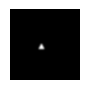

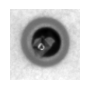

In [ ]:
# You can adjust the opacity to make the shape more or less visible
result = add_random_shape_to_mask_center(sm_img, sm_msk, shape_size_fraction=.3, blend_factor=0.8)
show_(result)

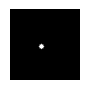

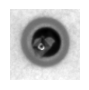

In [ ]:

# You can adjust the opacity to make the shape more or less visible
result = add_random_shape_to_mask_center_blend(sm_img, sm_msk, shape_size_fraction=.3, blend_factor=0.9)
show_(result)

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export('35_image_gen.synthetic_noise_at_center.ipynb')